# Mesh2HRTF / NumCalc evaluation  
## KEMAR + VR Headset 
## Microphone array I — far field MVDR beamforming <br> Fixed look direction $(1,0,0) m$

**Stéphane Dedieu** · Bloo Audio Inc. · Ottawa  
**17 September 2026**

Project: `Kemar_VRHeadset_v002`  
Solver: NumCalc (Mesh2HRTF 1.3.0), Burton–Miller BEM + FMM  
Grid: `EvaluationGrids/Default_1m` — **r = 1.0 m** sphere, 1850 points  
Source: `source_1` , `source_2` ,`source_3` ,`source_4`   (microphones 1,2,3,4)
Computed band: 100 Hz – 8 kHz (100 Hz steps)

Sanity-check notebook: read the nodes, 3D scatter, then relative \(20\log_{10}|p|\) maps.

## Introduction

This notebook post-processes a Mesh2HRTF / NumCalc run (Burton–Miller BEM, ML-FMM) for four reciprocal point sources on the KEMAR + VR headset. Each source stands for one microphone.

It loads the mesh, the microphone seats, the boundary pressure, the field on the unit sphere, and the transfer functions from microphones 1–4 to (1, 0, 0).

Beamforming weights are not computed here.

## 1. KEMAR + VR headset: the CAD file

High-resolution geometry of a KEMAR-style head integrated with a **generic** VR headset.  
Used as the domain for **open-source BEM** (Mesh2HRTF / NumCalc) to compute microphone transfer functions.
This is an in-house concept mesh for open BEM (Mesh2HRTF / NumCalc).
It is **not** a vendor product and is **not** affiliated with any commercial VR headset.

## 2. Linear microphone array — look direction $(1,0,0) m$

Four reciprocal point sources sit $2 \mathrm{mm}$ off the skin on the right side of the headset, $2.5 \mathrm{cm}$ apart, on a linear end-fire line. Each NumCalc run is the transfer function $H_m(f;\mathbf{r})$ between seat $m=1,2,3,4$ and the field. 
The design look is the $1 \mathrm{m}$ station $\mathbf{r}=(1,0,0)\,\mathrm{m}$ ($+x$, nose). The beam is **fixed frontal**: one steering vector toward that point.
The rest of the $\sim 1850$-point unit sphere is only used to plot the pattern and to build the isotropic covariance.


## 3. How to run the simulation. 

The folders `Kemar_VRHeadset_v002/NumCalc/source_1` … `source_4`  **contain no results**. Only the input file `NC.inp` is there. <br>
Run the simulation as described below before post-processing.

NumCalc is a Unix binary. On Windows, install **WSL2** with Ubuntu 22.04 and open that terminal (not PowerShell). <br>
In the Ubuntu window, for each subfolder `source_1` , `source_2` ,`source_3` ,`source_4`  run the following commands:

```bash
cd .../Kemar_VRHeadset_v002/NumCalc/source_1    
.../Mesh2HRTF-1.3.0/mesh2hrtf/NumCalc/bin/NumCalc   -istart 1  -iend 80  -nitermax 500
```
80 frequencies: 100:100:8000 Hz

## 4. Post-processing

- Import the boundary-element mesh and the .stl
- Microphone positions
- Pressure on the boundary, for one source (one microphone) and one frequency
- Pressure on the unit sphere, for one source and one frequency
- Transfer functions from microphones 1–4 to the point (1, 0, 0) m on the unit sphere


## Kemar+VR Headset Boundary Element Mesh  and .stl

In [ ]:
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
ref = Path(r".\Kemar_VRHeadset_v002\ObjectMeshes\Reference")

# Nodes: "N" puis "id x y z"
nraw = (ref / "Nodes.txt").read_text().strip().splitlines()
nodes = np.loadtxt(nraw[1:])
nid, xyz = nodes[:, 0].astype(int), nodes[:, 1:4]
# table id -> ligne (au cas ou les id ne sont pas 0..N-1 contigus)
imap = {int(i): k for k, i in enumerate(nid)}

# Elements: "M" puis "id n1 n2 n3 0 0 0"
eraw = (ref / "Elements.txt").read_text().strip().splitlines()
elems = np.loadtxt(eraw[1:], dtype=int)
tri = np.array([[imap[int(a)], imap[int(b)], imap[int(c)]]
                for a, b, c in elems[:, 1:4]])

fig = go.Figure(data=[go.Mesh3d(
    x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
    i=tri[:, 0], j=tri[:, 1], k=tri[:, 2],
    color="lightgray",
    opacity=1.0,
    flatshading=True,
)])


# aretes (optionnel, pour voir le maillage)
fig.add_trace(go.Scatter3d(
    x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
    mode="markers",
    marker=dict(size=1, color="black"),
    name="nodes",
))



fig.update_layout(
    title="Object mesh Reference — Humanoid_mic1_2",
    scene=dict(
        aspectmode="data",
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
    ),
)
fig.show()
print(len(nid), "nodes,", len(tri), "triangles")

###  Test Import  .stl  + Linear Array mics 1234

In [ ]:
from pathlib import Path
import numpy as np
import plotly.graph_objects as go

stl = Path(r".\Kemar_VRHeadset_v002\array51_kemar_vr.stl")
verts = []
for line in stl.read_text().splitlines():
    p = line.split()
    if p and p[0] == "vertex":
        verts.append([float(p[1]), float(p[2]), float(p[3])])
xyz = np.asarray(verts, dtype=float)
tri = xyz.reshape(-1, 3, 3)

edges = set()
for t in tri:
    for a, b in ((0, 1), (1, 2), (2, 0)):
        key = tuple(sorted((tuple(np.round(t[a], 6)), tuple(np.round(t[b], 6)))))
        edges.add(key)
xs, ys, zs = [], [], []
for a, b in edges:
    xs += [a[0], b[0], None]
    ys += [a[1], b[1], None]
    zs += [a[2], b[2], None]

pick = [0,1,2,3]   # rows 
pts = np.loadtxt(r".\Kemar_VRHeadset_v002\KemarVR_Headset_lin_mics1234.txt", skiprows=1)[pick]

fig = go.Figure()
fig.add_trace(go.Mesh3d(
    x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
    i=np.arange(0, len(xyz), 3),
    j=np.arange(1, len(xyz), 3),
    k=np.arange(2, len(xyz), 3),
    color="#f4f1ea", opacity=1.0, flatshading=True,
    lighting=dict(ambient=1.0, diffuse=0.0, specular=0.0),
    hoverinfo="skip", name="shell",
))
fig.add_trace(go.Scatter3d(
    x=xs, y=ys, z=zs, mode="lines",
    line=dict(color="#6b7c63", width=1),
    hoverinfo="skip", name="edges",
))
fig.add_trace(go.Scatter3d(
    x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
    mode="markers+text",
    marker=dict(size=5, color="crimson"),
    text=["1", "2", "3", "4"],
    textposition="top center",
    name="mics",
))
fig.update_layout(
    title="array51 — 4 mics",
    width=1000, height=1000,
    scene=dict(aspectmode="data"),
    margin=dict(l=0, r=0, t=40, b=0),
    showlegend=False,
)
fig.show()

### Post-processing pBoundary

Vertex-interpolated $|p|$ on the skin (Plotly `intensitymode=vertex`).
Colour scale clipped at the top ($c_{\max}=-1\,\mathrm{dB}$ re max) so the
near-source patch does not saturate the map.

In [ ]:
from pathlib import Path
import numpy as np
import plotly.graph_objects as go

ref = Path(r"C:\Users\stefo\m2h_head\Kemar_VRHeadset_v002\ObjectMeshes\Reference")
p_path = Path(r"C:\Users\stefo\m2h_head\Kemar_VRHeadset_v002\NumCalc\source_4\be.out\be.40\pBoundary")

# --- mesh ---
nraw = (ref / "Nodes.txt").read_text().strip().splitlines()
nodes = np.loadtxt(nraw[1:])
nid, xyz = nodes[:, 0].astype(int), nodes[:, 1:4]
imap = {int(i): k for k, i in enumerate(nid)}

eraw = (ref / "Elements.txt").read_text().strip().splitlines()
elems = np.loadtxt(eraw[1:], dtype=int)
tri = np.array([[imap[int(a)], imap[int(b)], imap[int(c)]]
                for a, b, c in elems[:, 1:4]])
eids = elems[:, 0].astype(int)

# --- pBoundary: 3 header lines, then id Re Im per element ---
praw = p_path.read_text().strip().splitlines()
pdata = np.loadtxt(praw[3:])
pid, pre, pim = pdata[:, 0].astype(int), pdata[:, 1], pdata[:, 2]
mag = np.hypot(pre, pim)
pmap = {int(i): m for i, m in zip(pid, mag)}
face_p = np.array([pmap[int(e)] for e in eids])

# --- element |p| -> vertices (display only) ---
vert_p = np.zeros(len(xyz))
vert_n = np.zeros(len(xyz))
for t, val in zip(tri, face_p):
    vert_p[t] += val
    vert_n[t] += 1
vert_p /= np.maximum(vert_n, 1)
vert_db = 20.0 * np.log10(np.maximum(vert_p, 1e-30) / np.max(face_p))

fig = go.Figure(data=[go.Mesh3d(
    x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
    i=tri[:, 0], j=tri[:, 1], k=tri[:, 2],
    intensity=vert_db,
    intensitymode="vertex",
    colorscale="jet",
    cmin=-70,
    cmax=0,
    colorbar=dict(title="dB re max"),
    flatshading=False,
)])
fig.update_layout(
    title="Mic 4: pBoundary |p| @ be.40 — 4000 Hz vertex interpolation",
    width=1100, height=800,
    scene=dict(aspectmode="data",
               xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
)
fig.show()
print("faces", len(face_p), "nodes", len(xyz))
print("dB min/max", vert_db.min(), vert_db.max())

##  Post Process results on Unit Sphere

###   Unit Sphere (r = 1m)  in Default_1m 

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


folder = Path(r".\Kemar_VRHeadset_v002\EvaluationGrids\Default_1m")

nodes_path = folder / "Nodes.txt"

raw = nodes_path.read_text().strip().splitlines()
n_decl = int(raw[0].split()[0])
data = np.loadtxt(raw[1:])
ids, xyz = data[:, 0], data[:, 1:4]
radii = np.linalg.norm(xyz, axis=1)

print(n_decl, "declared,", len(ids), "read")
print("radius m: min", radii.min(), "mean", radii.mean(), "max", radii.max())

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=6)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title("Default eval grid Unit Sphere — points only")
m = np.max(np.abs(xyz)) * 1.05
ax.set_xlim(-m, m)
ax.set_ylim(-m, m)
ax.set_zlim(-m, m)
plt.show()

### Pressure magnitude on Unit Sphere  -  Microphone n. 4  -  1000 Hz

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# here:  result be.10 =  1000 Hz, source_4 = microphone n. 4  or  mic_4 

p_path = Path(r"C:\Users\stefo\m2h_head\Kemar_VRHeadset_v002\NumCalc\source_4\be.out\be.10\pEvalGrid")  

raw = p_path.read_text().strip().splitlines()
# 3 premieres lignes = header Mesh2HRTF
pdata = np.loadtxt(raw[3:])
pid, pre, pim = pdata[:, 0], pdata[:, 1], pdata[:, 2]  # pid, real(pressure), imag(pressure)
mag = np.hypot(pre, pim)
db = 20.0 * np.log10(np.maximum(mag, 1e-30) / mag.max())   # dB relatifs

print("points", len(pid), " |p| min/max", mag.min(), mag.max())
print("dB rel min", db.min())

# xyz doit deja exister (cellule Nodes). Alignement par id :
order = {int(i): k for k, i in enumerate(ids.astype(int))}
idx = np.array([order[int(i)] for i in pid])
xyz_p = xyz[idx]


# apres avoir mag, db, xyz_p
print("dB percentiles", np.percentile(db, [0, 1, 5, 50, 95, 99, 100]))

# masquer le ring pourri
ok = mag > (np.median(mag) * 1e-3)    # garde l'essentiel
print("points gardes", ok.sum(), "/", len(ok))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    xyz_p[ok, 0], xyz_p[ok, 1], xyz_p[ok, 2],
    s=8, c=db[ok], cmap="jet", vmin=-2, vmax=0
)
plt.colorbar(sc, ax=ax, shrink=0.6, label="dB re max (clip -2..0)")
ax.set_title("mic_4 @ 1 kHz — Magnitude pressure on Unit Sphere (1 m) ")
m = 2
ax.set_xlim(-m, m); ax.set_ylim(-m, m); ax.set_zlim(-m, m)
ax.set_xlabel('X')
ax.set_ylabel('Y'); 
ax.set_zlabel('Z'); 
plt.show()

### Pressure real part on Unit Sphere  -  Microphone n. 4  -  1000 Hz

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(xyz_p[:, 0], xyz_p[:, 1], xyz_p[:, 2],
                s=8, c=pre, cmap="coolwarm")             # pre= real part (pressure)
plt.colorbar(sc, ax=ax, shrink=0.6, label="Re(p)")
ax.set_title("Re(p) @ 1 kHz  mic_4  Unit Sphere")
m = 1.6
ax.set_xlim(-m, m); ax.set_ylim(-m, m); ax.set_zlim(-m, m)
ax.set_xlabel('X')
ax.set_ylabel('Y'); 
ax.set_zlabel('Z'); 
plt.show()

print("Re min/max", pre.min(), pre.max())
print("phase std (deg)", np.std(np.angle(pre + 1j*pim)) * 180/np.pi)

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
    x=xyz_p[:, 0], y=xyz_p[:, 1], z=xyz_p[:, 2],
    mode="markers",
    marker=dict(size=3, color=pre, colorscale="RdBu",
                colorbar=dict(title="Re(p)"))
)])


fig.update_layout(
    title="Re(p) @ 1 kHz  mic_4  Unit Sphere — drag to rotate",
    width=500, height=500,
    scene=dict(
        aspectmode="data",
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
    ),
)
fig.show()

###  Transfer Function mics 1234 to point at 1 meter  0 deg in xoy plane

gid 200889 [1. 0. 0.]


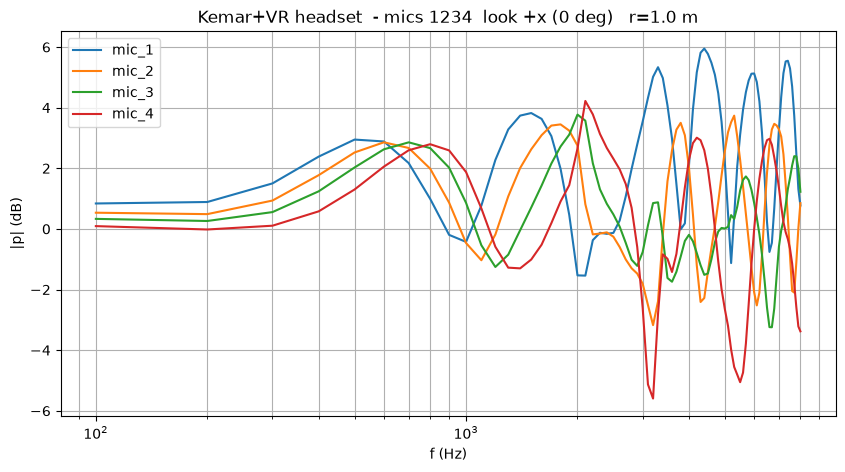

In [20]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

proj = Path(r".\Kemar_VRHeadset_v002")
nodes_path = proj / "EvaluationGrids" / "Default_1m" / "Nodes.txt"
r, f0, df, nfreq = 1., 100.0, 100.0, 80
mics = [1, 2, 3, 4]          # source_1 = mic13, etc.
#mics = [1, 2]          # source_1 = mic13, etc.
#mics = [2, 3, 4]          # source_1 = mic13, etc.

ndata = np.loadtxt(nodes_path.read_text().splitlines()[1:])
gids, gxyz = ndata[:, 0].astype(int), ndata[:, 1:4]
target = np.array([r, 0.0, 0.0])      # look +x ; change si besoin
gid = int(gids[np.argmin(((gxyz - target)**2).sum(1))])
print("gid", gid, gxyz[gids == gid][0])

def load_p(folder, gid):
    freqs, p = [], []
    root = proj / "NumCalc" / folder / "be.out"
    for i in range(1, nfreq + 1):
        f = root / f"be.{i}" / "pEvalGrid"
        if not f.exists():
            break
        row = np.loadtxt(f.read_text().splitlines()[3:])
        row = row[row[:, 0] == gid][0]
        freqs.append(f0 + (i - 1) * df)
        p.append(row[1] + 1j * row[2])
    return np.array(freqs), np.array(p)


mic_label = [None, "mic_1", "mic_2", "mic_3", "mic_4"]   # source_k -> mic k
plt.figure(figsize=(10, 5))
for k in mics:
    folder = f"source_{k}"
    freqs, p = load_p(folder, gid)
    if len(freqs) == 0:
        print("vide", folder)
        continue
    #plt.semilogx(freqs, 20 * np.log10(np.abs(4*np.pi*p)), label=folder)
    plt.semilogx(freqs, 20 * np.log10(np.abs(4 * np.pi * p)), label=mic_label[k])
plt.xlabel("f (Hz)")
plt.ylabel("|p| (dB)")
plt.title("Kemar+VR headset  - mics 1234  look +x (0 deg)   r=1.0 m")
plt.grid(True, which="both")
plt.legend()
plt.show()

## Low-frequency TFs

Against a trusted reference BEM/FEM run, Mesh2HRTF / NumCalc stays within about $0.2\,\mathrm{dB}$ below $500\,\mathrm{Hz}$ on **mic1** and
**mic2**. The same offset showed up on the rigid-sphere check at small $ka$. We treat it as a limitation of the collocation BEM + FMM, not as
a geometry error. 

For array design that offset is not cosmetic. Magnitude mismatch between seats degrades a superdirective MVDR pattern in the same band.
The weights are therefore given a tighter white-noise-gain floor below $400$–$500\,\mathrm{Hz}$ ($-25\,\mathrm{dB}$, then a ramp toward
$-30\,\mathrm{dB}$ above $1\,\mathrm{kHz}$). That extra regularisation keeps $w_{\mathrm{opt}}(f)$ and the directivity index smooth instead of
fitting the $0.2\,\mathrm{dB}$ solver noise.

### Dimensionless frequency \(ka\)  
Rigid sphere, \(a = 0.1\,\mathrm{m}\), \(c = 346.18\,\mathrm{m/s}\) (NumCalc)

| \(f\) (Hz) | \(\lambda\) (m) | \(k\) (m\(^{-1}\)) | \(ka\) |
|-----------:|----------------:|-------------------:|-------:|
| 100 | 3.462 | 1.815 | **0.18** |
| 500 | 0.692 | 9.075 | **0.91** |
| 1000 | 0.346 | 18.15 | **1.82** |
| 2000 | 0.173 | 36.30 | **3.63** |
| 4000 | 0.087 | 72.60 | **7.26** |
| 8000 | 0.043 | 145.2 | **14.52** |

Low \(ka\): near-monopole after piston correction.  
\(ka \gtrsim 1\): scattering onsets.  
\(ka \approx 14.5\): short-wavelength regime (pole mesh still untrusted).